In [ ]:
# Dataset - https://www.kaggle.com/datasets/salader/dogs-vs-cats

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d salader/dogs-vs-cats

100% 1.06G/1.06G [00:53<00:00, 24.5MB/s]
100% 1.06G/1.06G [00:53<00:00, 21.5MB/s]


In [ ]:
import zipfile
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Extract the dataset
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
# Load and preprocess data
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 5000 files belonging to 2 classes.


In [ ]:
# Normalize
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label


In [ ]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 [==============================] - 80s 111ms/step - loss: 1.2772 - accuracy: 0.5929 - val_loss: 0.6010 - val_accuracy: 0.7052
Epoch 2/10
625/625 [==============================] - 67s 106ms/step - loss: 0.5695 - accuracy: 0.7110 - val_loss: 0.5366 - val_accuracy: 0.7314
Epoch 3/10
625/625 [==============================] - 68s 108ms/step - loss: 0.4777 - accuracy: 0.7679 - val_loss: 0.5819 - val_accuracy: 0.7130
Epoch 4/10
625/625 [==============================] - 67s 106ms/step - loss: 0.4268 - accuracy: 0.8062 - val_loss: 0.5351 - val_accuracy: 0.7392
Epoch 5/10
625/625 [==============================] - 69s 110ms/step - loss: 0.3733 - accuracy: 0.8349 - val_loss: 0.4718 - val_accuracy: 0.7874
Epoch 6/10
625/625 [==============================] - 69s 110ms/step - loss: 0.2996 - accuracy: 0.8705 - val_loss: 0.7910 - val_accuracy: 0.7046
Epoch 7/10
625/625 [==============================] - 67s 107ms/step - loss: 0.2149 - accuracy: 0.9098 - val_loss: 0.6653 - val_ac

In [ ]:
# Extract features from the last convolutional layer
extractor_model = Sequential(model.layers[:-3])  # Remove Dense layers
features = extractor_model.predict(validation_ds)

157/157 [==============================] - 7s 44ms/step


In [ ]:
# Flatten the features for k-means clustering
flattened_features = features.reshape(features.shape[0], -1)

In [ ]:
# Apply k-means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(flattened_features)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
# Get true labels
true_labels = np.concatenate([y for x, y in validation_ds], axis=0)

In [ ]:
# Calculate confusion matrix
conf_matrix = confusion_matrix(true_labels, cluster_labels)

# Create DataFrames for user's and producer's confusion matrices with class labels
unique_classes = np.unique(true_labels)
user_conf_matrix = pd.DataFrame(confusion_matrix(true_labels, cluster_labels, labels=unique_classes),
                                index=unique_classes, columns=unique_classes)
producer_conf_matrix = pd.DataFrame(confusion_matrix(cluster_labels, true_labels, labels=unique_classes),
                                    index=unique_classes, columns=unique_classes)

# Add total columns and rows
user_conf_matrix['Total'] = user_conf_matrix.sum(axis=1)
user_conf_matrix.loc['Total'] = user_conf_matrix.sum()

producer_conf_matrix['Total'] = producer_conf_matrix.sum(axis=1)
producer_conf_matrix.loc['Total'] = producer_conf_matrix.sum()

# Convert confusion matrices to percentages
user_conf_matrix_percentage = user_conf_matrix.div(user_conf_matrix['Total'], axis=0) * 100
producer_conf_matrix_percentage = producer_conf_matrix.div(producer_conf_matrix['Total'], axis=0) * 100

In [ ]:
# Print the confusion matrices
print("Confusion Matrix:")
print(conf_matrix)

print("\nUser's Confusion Matrix (Percentage):")
print(user_conf_matrix_percentage)

print("\nProducer's Confusion Matrix (Percentage):")
print(producer_conf_matrix_percentage)


Confusion Matrix:
[[ 919 1581]
 [ 938 1562]]

User's Confusion Matrix (Percentage):
           0      1  Total
0      36.76  63.24  100.0
1      37.52  62.48  100.0
Total  37.14  62.86  100.0

Producer's Confusion Matrix (Percentage):
               0          1  Total
0      49.488422  50.511578  100.0
1      50.302259  49.697741  100.0
Total  50.000000  50.000000  100.0


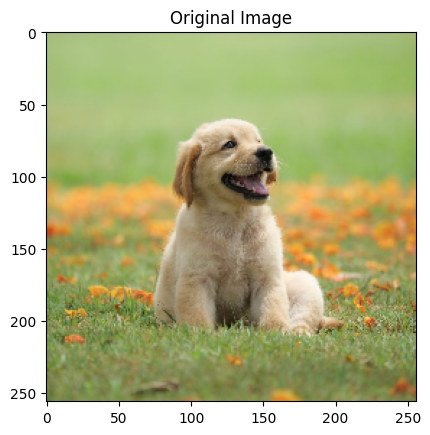

1/1 [==============================] - 0s 28ms/step
Model Prediction:
The image is classified as a Dog with confidence 82.41%.


In [ ]:
# Load an image for classification
image_path = 'test_img.jpg'
test_img = cv2.imread(image_path)
test_img = cv2.resize(test_img, (256, 256))  # Resize to match the model's input size

# Display the original image
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.show()

# Normalize the image
test_input = test_img.reshape((1, 256, 256, 3)).astype(np.float32) / 255.

# Use the trained model for prediction
prediction = model.predict(test_input)
predicted_label = "Cat" if prediction[0, 0] < 0.5 else "Dog"

print("Model Prediction:")
print(f"The image is classified as a {predicted_label} with confidence {prediction[0, 0] * 100:.2f}%.")
